In [1]:
import seaborn as sns
penguins_df = sns.load_dataset('penguins').dropna()

penguins_df


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


17 outliers were detected and removed.
Generating boxplots to compare data before and after outlier removal...


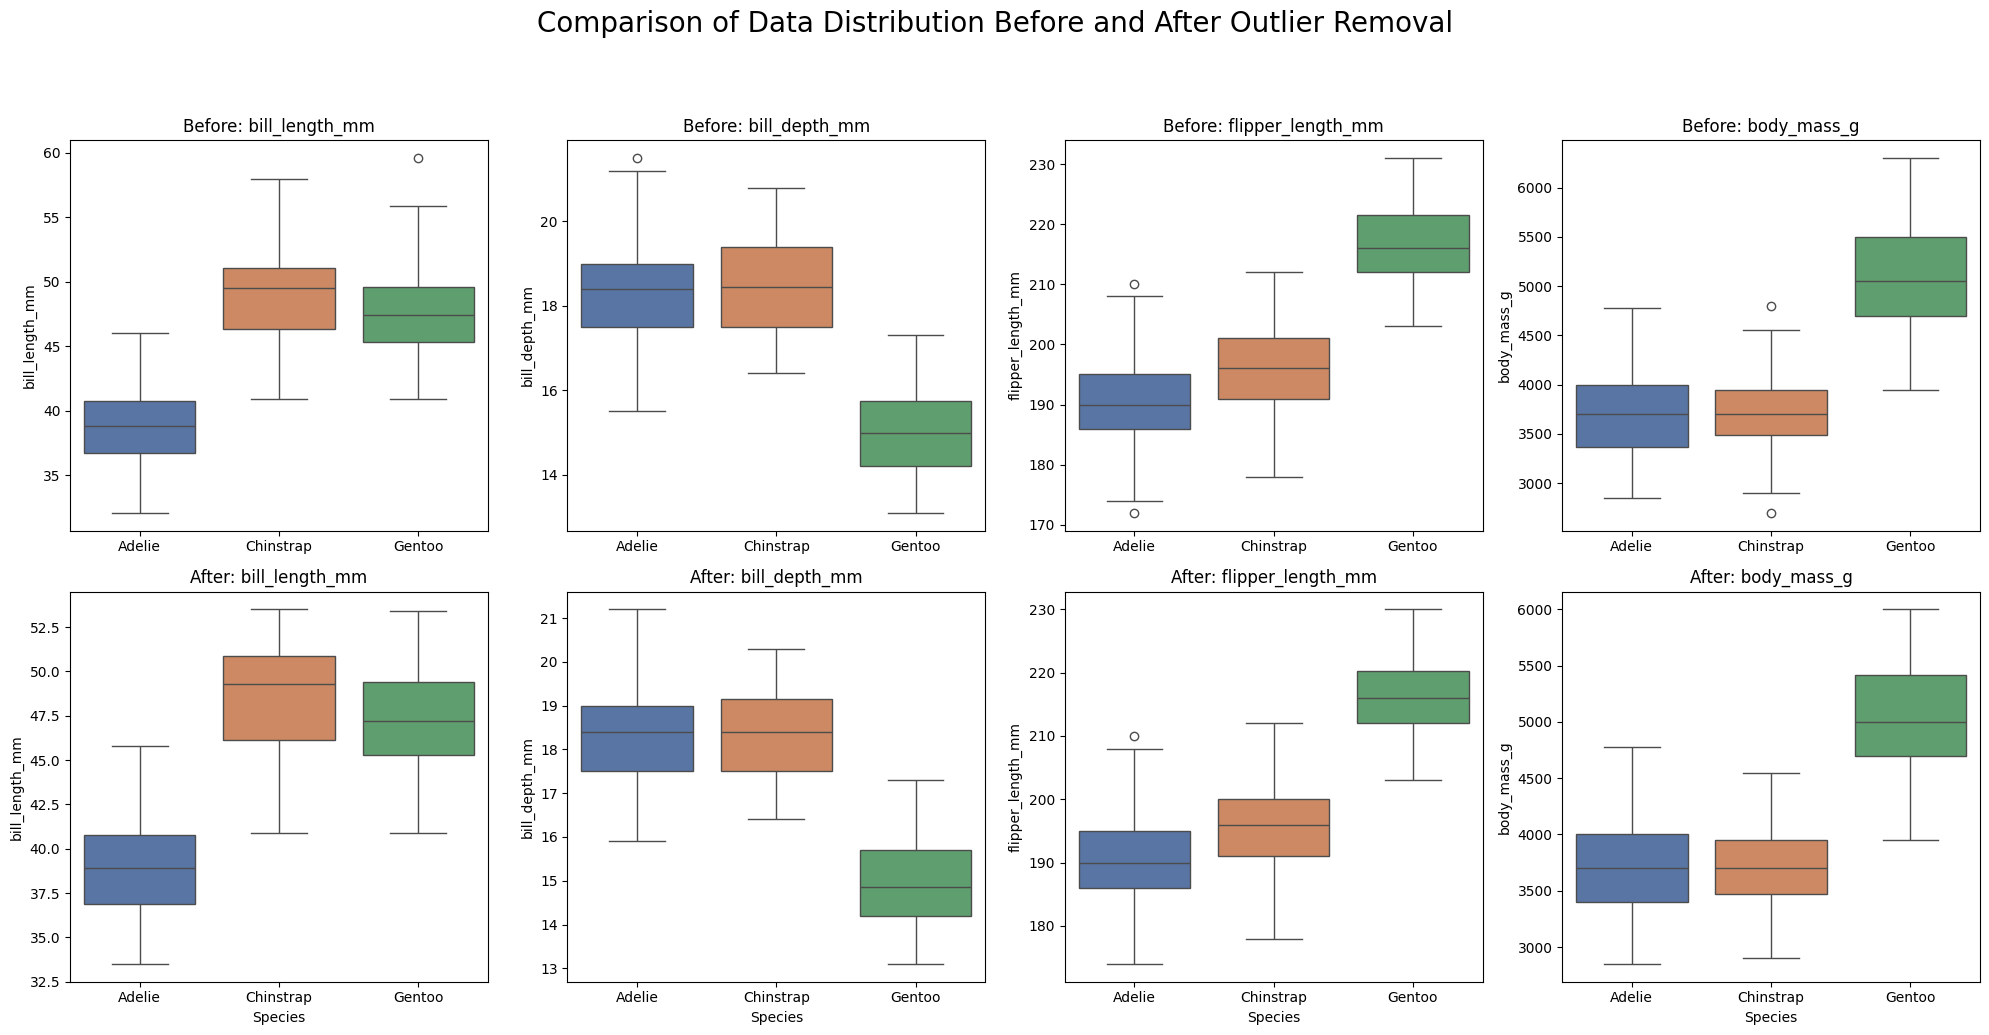

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
penguins_df = sns.load_dataset('penguins').dropna()


numerical_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

X = penguins_df[numerical_features]

# ปรับสเกลข้อมูลเพื่อประสิทธิภาพที่ดีขึ้น
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# สร้างและสอนโมเดล IsolationForest
# contamination=0.05 หมายถึงเราสันนิษฐานว่าประมาณ 5% ของข้อมูลเป็น outliers
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_predictions = iso_forest.fit_predict(X_scaled)

# เลือกเฉพาะข้อมูลที่เป็น inliers (โมเดลทำนายเป็น 1)
inlier_indices = np.where(outlier_predictions == 1)[0]
penguins_clean_df = penguins_df.iloc[inlier_indices]

print(f"{len(penguins_df) - len(penguins_clean_df)} outliers were detected and removed.")


# --- Part 1.75: Visualize Outlier Removal with Boxplots ---
print("Generating boxplots to compare data before and after outlier removal...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Comparison of Data Distribution Before and After Outlier Removal', fontsize=20, y=1.03)

# วาด Box plots สำหรับข้อมูล "ก่อน" การกำจัด Outlier
for i, feature in enumerate(numerical_features):
    sns.boxplot(ax=axes[0, i], data=penguins_df, x='species', y=feature, hue='species', palette='deep', legend=False)
    axes[0, i].set_title(f'Before: {feature}')
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel(feature)

# วาด Box plots สำหรับข้อมูล "หลัง" การกำจัด Outlier
for i, feature in enumerate(numerical_features):
    sns.boxplot(ax=axes[1, i], data=penguins_clean_df, x='species', y=feature, hue='species', palette='deep', legend=False)
    axes[1, i].set_title(f'After: {feature}')
    axes[1, i].set_xlabel('Species')
    axes[1, i].set_ylabel(feature)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


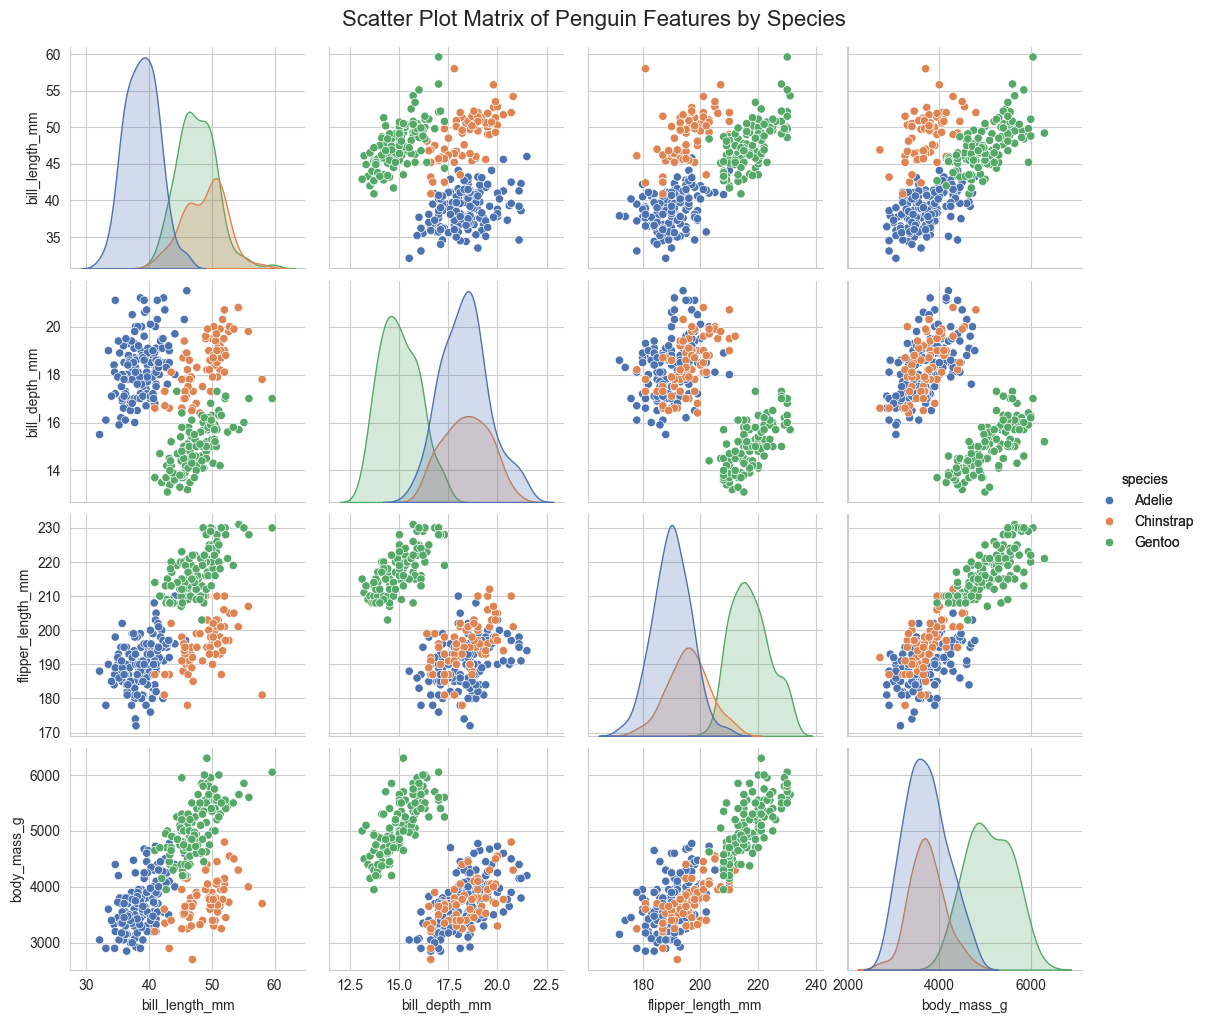

In [3]:
# ตั้งค่าสไตล์ของกราฟให้สวยงาม
sns.set_style("whitegrid")

# สร้าง Pair Plot โดยใช้ seaborn
# hue='species' คือคำสั่งสำคัญในการแยกสีตามสายพันธุ์
pair_plot = sns.pairplot(penguins_df, hue='species', palette='deep', diag_kind='kde')

# เพิ่มหัวข้อหลักให้กับกราฟทั้งหมด
pair_plot.fig.suptitle("Scatter Plot Matrix of Penguin Features by Species", y=1.02, fontsize=16)

# แสดงกราฟ
pair_plot.add_legend()

,species
111,Adelie
28,Adelie
18,Adelie
284,Gentoo
211,Chinstrap
...,...
76,Adelie
302,Gentoo
128,Adelie
82,Adelie


--- SVM Classification Report ---
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        30
   Chinstrap       0.87      0.93      0.90        14
      Gentoo       0.96      0.96      0.96        25

    accuracy                           0.96        69
   macro avg       0.94      0.95      0.95        69
weighted avg       0.96      0.96      0.96        69

--------------------------------------------------
--- Generating Confusion Matrix ---


/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64569/1783838978.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguins_df['sex'].fillna(sex_mode, inplace=True)


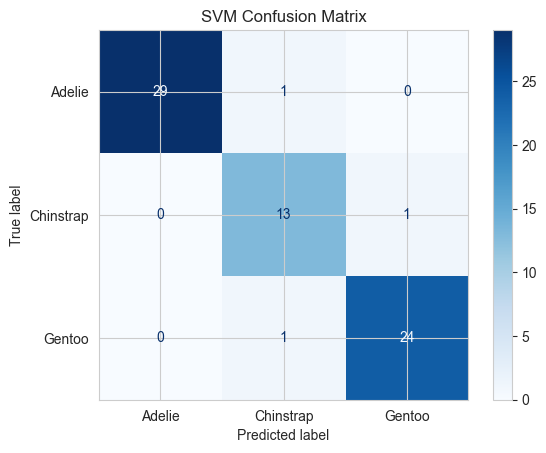

Generating plot with decision boundary...


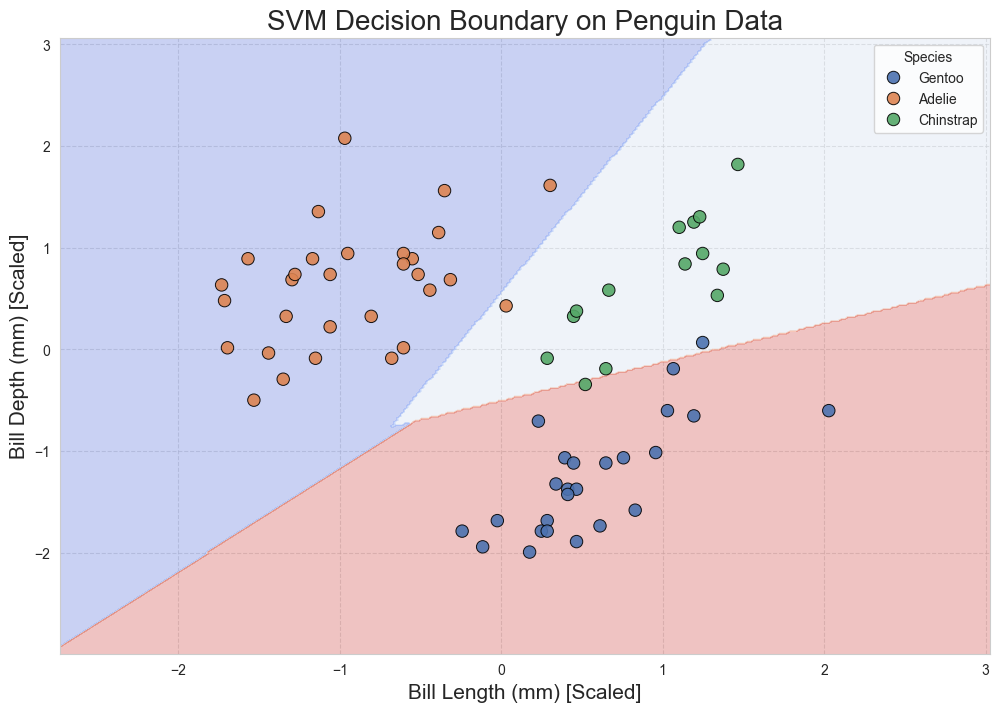

In [4]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- 1. Load the Dataset ---
# โหลดชุดข้อมูลเพนกวิน
penguins_df = sns.load_dataset("penguins")


#หา ค่าฐานนิยมของเพศ
sex_mode = penguins_df['sex'].mode().iloc[0]
#เติมค่า เพศที่เป็นฐานนิยมลงในข้อมูลว่าง
penguins_df['sex'].fillna(sex_mode, inplace=True)



# --- 4. Drop Rows with Missing Data in Key Columns ---
cols_to_check = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species']

# ตรวจสอบจำนวนค่า null ในคอลัมน์ที่เลือก ก่อนทำการลบ


# ใช้ .dropna() เพื่อลบแถวที่มีค่า null ในคอลัมน์ที่ระบุ
penguins_df.dropna(subset=cols_to_check, inplace=True)

# --- Part 2: Model Preparation ---
# 1. เลือก Features ที่ต้องการ
features = ['bill_length_mm', 'bill_depth_mm']
target = 'species'

X = penguins_df[features]
y = penguins_df[target]

# 2. แบ่งข้อมูลเป็นชุดสำหรับสอน (train) และทดสอบ (test)
# test_size=0.2 หมายถึงแบ่งข้อมูล 20% ไว้สำหรับทดสอบ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45, stratify=y)

# 3. ปรับสเกลข้อมูล (สำคัญมากสำหรับ SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Part 3: SVM Training and Evaluation ---
# 1. สร้างและสอนโมเดล SVM
# kernel='linear' คือการหาเส้นแบ่งที่เป็นเส้นตรง
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)
# 2. ทำนายผลกับข้อมูลทดสอบ
y_pred = svm_model.predict(X_test_scaled)

# 3. แสดง Classification Report
print("--- SVM Classification Report ---")
report = classification_report(y_test, y_pred)
print(report)
print("-" * 50)
# 3.5. สร้างและแสดง Confusion Matrix
print("--- Generating Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)

# วาด Confusion Matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('SVM Confusion Matrix')
plt.show()

# --- Part 4: Visualization of Decision Boundary ---
print("Generating plot with decision boundary...")

def plot_decision_boundary(X, y, model, scaler):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # map species to numbers for coloring the background
    species_map = {species: i for i, species in enumerate(np.unique(y))}

    # Predict for each point in the mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.array([species_map[label] for label in Z])
    Z = Z.reshape(xx.shape)

    # Plot the background and the data points
    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

    # Plot the test data points
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y,
                    palette='deep', s=80, edgecolor='k', alpha=0.9)

    plt.title('SVM Decision Boundary on Penguin Data', fontsize=20)
    plt.xlabel('Bill Length (mm) [Scaled]', fontsize=15)
    plt.ylabel('Bill Depth (mm) [Scaled]', fontsize=15)
    plt.legend(title='Species')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Visualize with the scaled test data
plot_decision_boundary(X_test_scaled, y_test.values, svm_model, scaler)

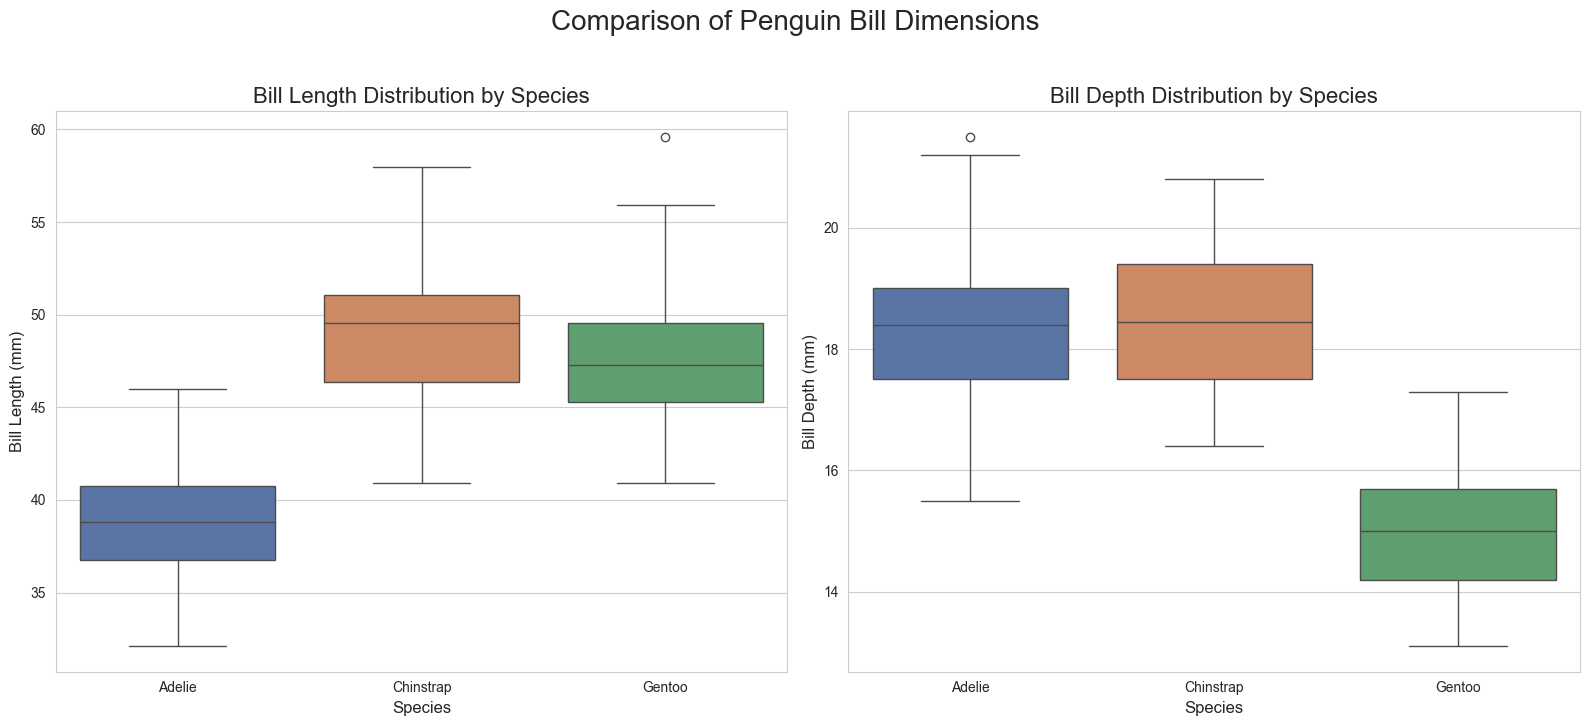

In [5]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Load and Prepare Data ---
# โหลดชุดข้อมูลเพนกวิน
# Seaborn's boxplot handles missing values gracefully, so no need for extensive cleaning for this visualization.
penguins_df = sns.load_dataset("penguins")

# --- 2. Create the Box Plots ---
# ตั้งค่าสไตล์ของกราฟ
sns.set_style("whitegrid")

# สร้าง Figure และ 2 Axes (1 แถว, 2 คอลัมน์) เพื่อวางกราฟข้างกัน
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- กราฟที่ 1: Bill Length ---
sns.boxplot(
    ax=axes[0],               # กำหนดให้วาดบนแกนแรก (ซ้าย)
    data=penguins_df,
    x='species',
    y='bill_length_mm',
    hue='species',              # แยกสีตามสายพันธุ์
    palette='deep',
    legend=False                # ซ่อน legend ใน subplot เพื่อไม่ให้ซ้ำซ้อน
)
axes[0].set_title('Bill Length Distribution by Species', fontsize=16)
axes[0].set_xlabel('Species', fontsize=12)
axes[0].set_ylabel('Bill Length (mm)', fontsize=12)

# --- กราฟที่ 2: Bill Depth ---
sns.boxplot(
    ax=axes[1],               # กำหนดให้วาดบนแกนที่สอง (ขวา)
    data=penguins_df,
    x='species',
    y='bill_depth_mm',
    hue='species',              # แยกสีตามสายพันธุ์
    palette='deep',
    legend=False
)
axes[1].set_title('Bill Depth Distribution by Species', fontsize=16)
axes[1].set_xlabel('Species', fontsize=12)
axes[1].set_ylabel('Bill Depth (mm)', fontsize=12)


# --- 3. Final Touches and Display ---
# เพิ่มหัวข้อหลักให้กับ Figure ทั้งหมด
fig.suptitle('Comparison of Penguin Bill Dimensions', fontsize=20, y=1.03)

# จัดการ layout ให้สวยงาม ไม่ซ้อนทับกัน
plt.tight_layout()

# แสดงกราฟ
plt.show()

--- Running t-SNE with different perplexity values ---
Calculating for perplexity = 5...


/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Calculating for perplexity = 30...


/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Calculating for perplexity = 50...


/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Calculations complete.


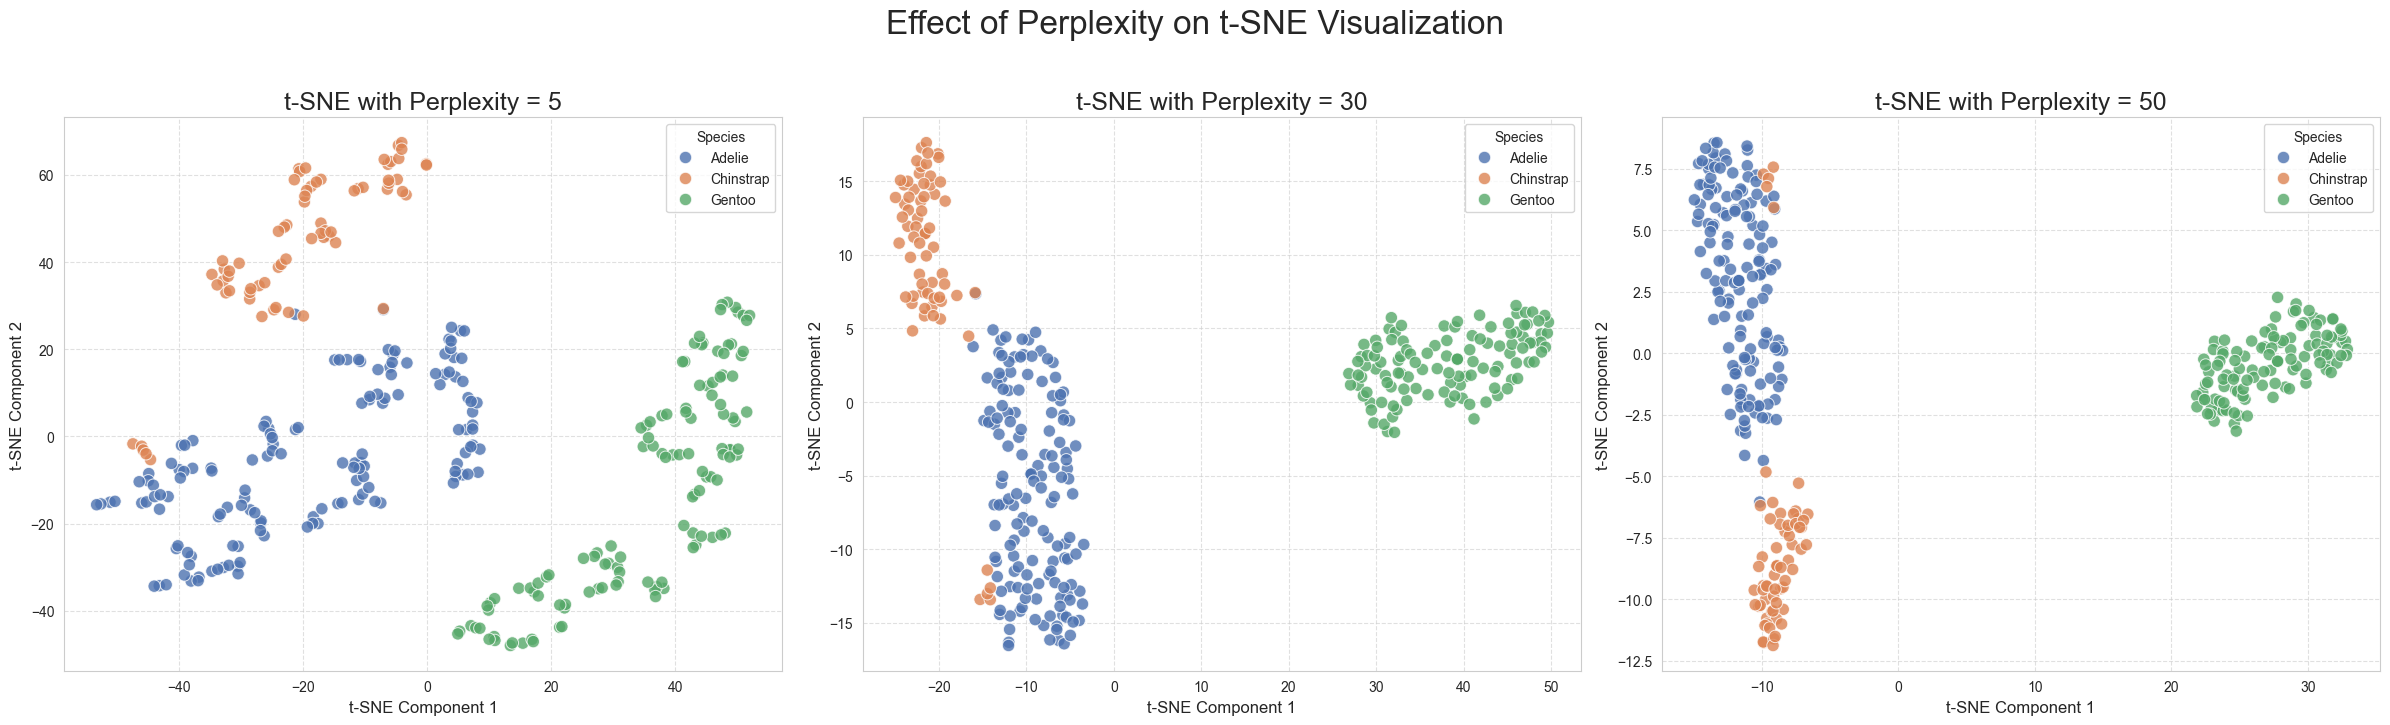

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

# --- 1. Load, Prepare, and Clean Data (using aggressive imputation) ---
penguins_df = sns.load_dataset("penguins").dropna().reset_index(drop=True)
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_df[features]
y = penguins_df['species']

X_scaled = StandardScaler().fit_transform(X)

# Using the aggressive outlier detection from the previous step
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_predictions = iso_forest.fit_predict(X_scaled)
outlier_indices = np.where(outlier_predictions == -1)[0]

penguins_imputed_df = penguins_df.copy()
species_means = penguins_df.groupby('species')[features].mean()
for idx in outlier_indices:
    outlier_species = penguins_imputed_df.loc[idx, 'species']
    imputation_values = species_means.loc[outlier_species]
    penguins_imputed_df.loc[idx, features] = imputation_values

X_imputed = penguins_imputed_df[features]
X_imputed_scaled = StandardScaler().fit_transform(X_imputed)

# --- 2. Run t-SNE with Different Perplexity Values ---
perplexity_values = [5, 30, 50]
tsne_results = {}

print("--- Running t-SNE with different perplexity values ---")
for p in perplexity_values:
    print(f"Calculating for perplexity = {p}...")
    tsne = TSNE(n_components=2, perplexity=p, random_state=42, n_iter=1000)
    tsne_components = tsne.fit_transform(X_imputed_scaled)

    tsne_df = pd.DataFrame(data=tsne_components, columns=['t-SNE Component 1', 't-SNE Component 2'])
    tsne_df['species'] = y.values
    tsne_results[p] = tsne_df

print("Calculations complete.")

# --- 3. Visualize the Results Side-by-Side ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for i, p in enumerate(perplexity_values):
    ax = axes[i]
    data_to_plot = tsne_results[p]

    sns.scatterplot(
        x='t-SNE Component 1', y='t-SNE Component 2',
        hue='species', data=data_to_plot,
        palette='deep', s=80, alpha=0.8, ax=ax
    )

    ax.set_title(f't-SNE with Perplexity = {p}', fontsize=18)
    ax.set_xlabel('t-SNE Component 1', fontsize=12)
    ax.set_ylabel('t-SNE Component 2', fontsize=12)
    ax.legend(title='Species')
    ax.grid(True, linestyle='--', alpha=0.6)

fig.suptitle('Effect of Perplexity on t-SNE Visualization', fontsize=24, y=1.03)
plt.tight_layout()
plt.show()

In [7]:
penguins_df = sns.load_dataset("penguins")
penguins_df.to_excel('penguins.xlsx', index=False)


--- Granular Outlier Handling using IQR per Species ---


/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64569/284130004.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguins_df['sex'].fillna(sex_mode, inplace=True)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female



[SUCCESS] Outliers have been imputed based on species-specific means.
--- SVM Classification Report ---
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        30
   Chinstrap       0.93      0.93      0.93        14
      Gentoo       1.00      0.96      0.98        25

    accuracy                           0.97        69
   macro avg       0.97      0.96      0.96        69
weighted avg       0.97      0.97      0.97        69

--------------------------------------------------
--- Generating Confusion Matrix ---


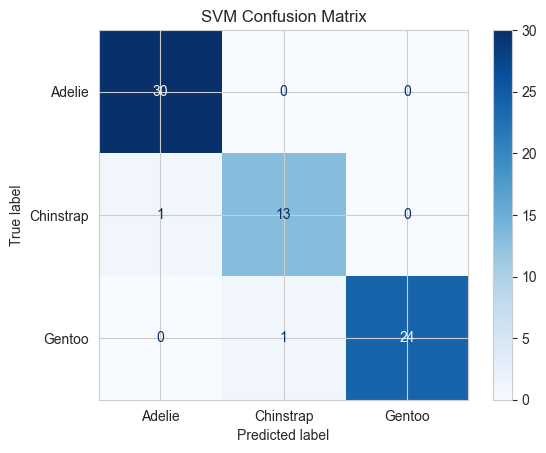

Generating plot with decision boundary...


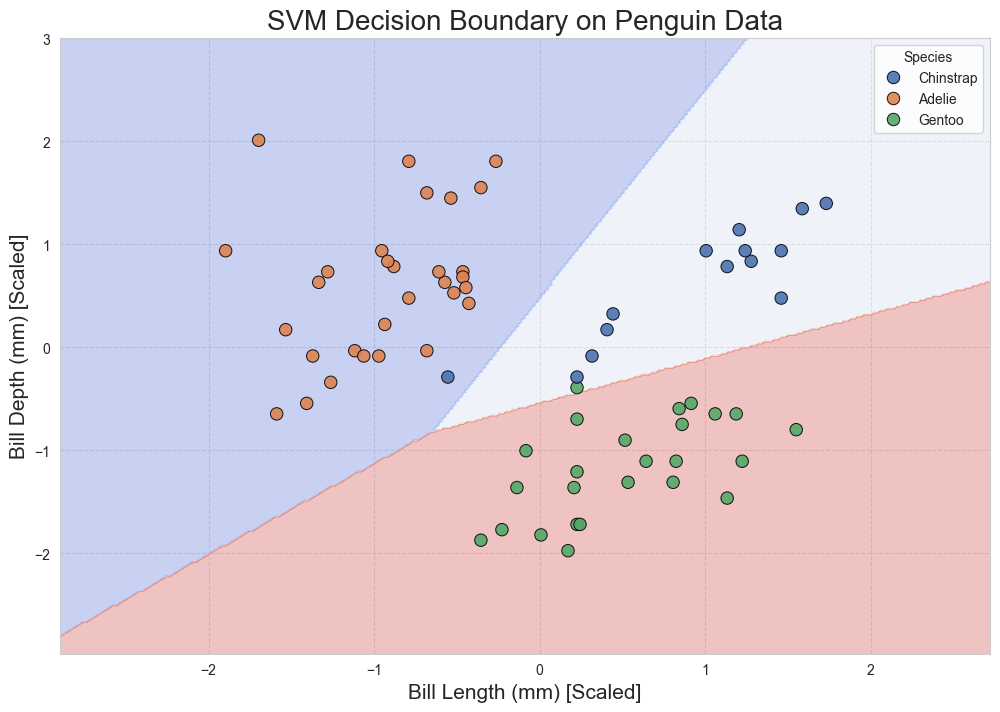

In [8]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- 1. Load the Dataset ---
# โหลดชุดข้อมูลเพนกวิน
penguins_df = sns.load_dataset("penguins")



sex_mode = penguins_df['sex'].mode().iloc[0]
penguins_df['sex'].fillna(sex_mode, inplace=True)



# --- 4. Drop Rows with Missing Data in Key Columns ---
cols_to_check = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species']

# ตรวจสอบจำนวนค่า null ในคอลัมน์ที่เลือก ก่อนทำการลบ


# ใช้ .dropna() เพื่อลบแถวที่มีค่า null ในคอลัมน์ที่ระบุ
penguins_df.dropna(subset=cols_to_check, inplace=True)


# --- 2. Granular Outlier Detection and Imputation using IQR ---
print("--- Granular Outlier Handling using IQR per Species ---")
penguins_imputed_df = penguins_df.copy()
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
# ใช้ set เพื่อเก็บ index ของ outlier ที่จะไม่ซ้ำกัน
outlier_indices_to_impute = set()

# วนลูปในแต่ละสายพันธุ์
for species in penguins_imputed_df['species'].unique():
    species_df = penguins_imputed_df[penguins_imputed_df['species'] == species]

    # วนลูปในแต่ละ feature ที่เป็นตัวเลข
    for feature in features:
        # คำนวณ IQR และขอบเขต
        Q1 = species_df[feature].quantile(0.25)
        Q3 = species_df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # ค้นหา outliers สำหรับ attribute และสายพันธุ์นี้
        outliers = species_df[(species_df[feature] < lower_bound) | (species_df[feature] > upper_bound)]


        # คำนวณค่าเฉลี่ยของแต่ละสายพันธุ์เตรียมไว้
        species_means = penguins_df.groupby('species')[features].mean()

        # เติมค่า outlier ที่พบด้วยค่าเฉลี่ยของสายพันธุ์นั้นๆ
        for idx in outlier_indices_to_impute:
            outlier_species = penguins_imputed_df.loc[idx, 'species']
            imputation_values = species_means.loc[outlier_species]
            penguins_imputed_df.loc[idx, features] = imputation_values


display(penguins_imputed_df)
print("\n[SUCCESS] Outliers have been imputed based on species-specific means.")

# --- Part 2: Model Preparation ---
# 1. เลือก Features ที่ต้องการ
features = ['bill_length_mm', 'bill_depth_mm']
target = 'species'

X = penguins_imputed_df[features]
y = penguins_imputed_df[target]

# 2. แบ่งข้อมูลเป็นชุดสำหรับสอน (train) และทดสอบ (test)
# test_size=0.2 หมายถึงแบ่งข้อมูล 20% ไว้สำหรับทดสอบ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

# 3. ปรับสเกลข้อมูล (สำคัญมากสำหรับ SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Part 3: SVM Training and Evaluation ---
# 1. สร้างและสอนโมเดล SVM
# kernel='linear' คือการหาเส้นแบ่งที่เป็นเส้นตรง
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)
# 2. ทำนายผลกับข้อมูลทดสอบ
y_pred = svm_model.predict(X_test_scaled)

# 3. แสดง Classification Report
print("--- SVM Classification Report ---")
report = classification_report(y_test, y_pred)
print(report)
print("-" * 50)
# 3.5. สร้างและแสดง Confusion Matrix
print("--- Generating Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)

# วาด Confusion Matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('SVM Confusion Matrix')
plt.show()

# --- Part 4: Visualization of Decision Boundary ---
print("Generating plot with decision boundary...")

def plot_decision_boundary(X, y, model, scaler):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # map species to numbers for coloring the background
    species_map = {species: i for i, species in enumerate(np.unique(y))}

    # Predict for each point in the mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.array([species_map[label] for label in Z])
    Z = Z.reshape(xx.shape)

    # Plot the background and the data points
    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

    # Plot the test data points
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y,
                    palette='deep', s=80, edgecolor='k', alpha=0.9)

    plt.title('SVM Decision Boundary on Penguin Data', fontsize=20)
    plt.xlabel('Bill Length (mm) [Scaled]', fontsize=15)
    plt.ylabel('Bill Depth (mm) [Scaled]', fontsize=15)
    plt.legend(title='Species')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Visualize with the scaled test data
plot_decision_boundary(X_test_scaled, y_test.values, svm_model, scaler)

Initial number of rows: 344
Rows after initial cleaning: 342
--------------------------------------------------
--- Granular Outlier Handling using IQR per Species ---
Found 6 outliers to impute.
Indices: [18, 27, 128, 188, 189, 252]

[SUCCESS] Outliers have been imputed based on species-specific means.
--------------------------------------------------
--- SVM Classification Report ---
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       0.87      0.93      0.90        14
      Gentoo       0.96      0.92      0.94        25

    accuracy                           0.96        69
   macro avg       0.94      0.95      0.95        69
weighted avg       0.96      0.96      0.96        69

--- Generating Confusion Matrix ---


/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64569/508767533.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguins_df['sex'].fillna(sex_mode, inplace=True)


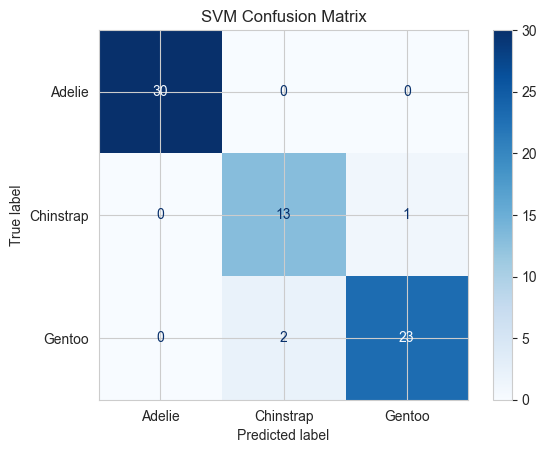


Generating plot with decision boundary...


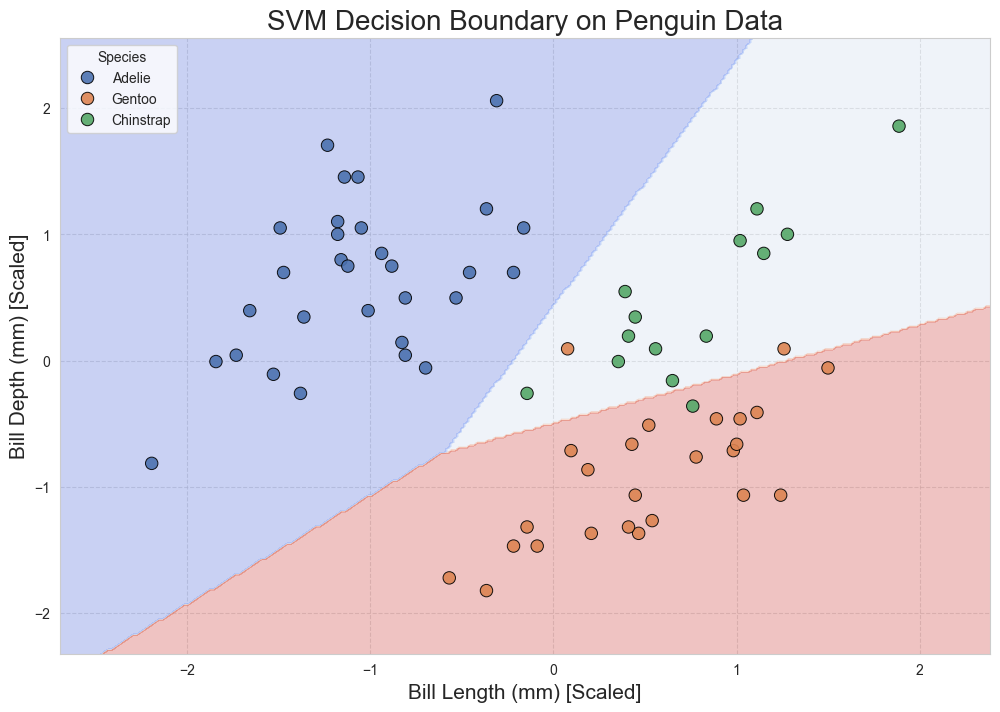

In [9]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Part 1: Load and Initial Data Cleaning ---
# โหลดชุดข้อมูลเพนกวิน
penguins_df = sns.load_dataset("penguins")
print(f"Initial number of rows: {len(penguins_df)}")

# 1.1 เติมค่า null ใน 'sex' ด้วย mode
sex_mode = penguins_df['sex'].mode().iloc[0]
penguins_df['sex'].fillna(sex_mode, inplace=True)

# 1.2 ลบแถวที่มีค่า null ในคอลัมน์สำคัญอื่นๆ
penguins_df.dropna(inplace=True)
penguins_df.reset_index(drop=True, inplace=True)
print(f"Rows after initial cleaning: {len(penguins_df)}")
print("-" * 50)


# --- Part 2: Granular Outlier Detection and Imputation using IQR ---
print("--- Granular Outlier Handling using IQR per Species ---")
penguins_imputed_df = penguins_df.copy()
features_all = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
outlier_indices_to_impute = set()

# Step A: Identify all outliers first
for species in penguins_imputed_df['species'].unique():
    species_df = penguins_imputed_df[penguins_imputed_df['species'] == species]
    for feature in features_all:
        Q1 = species_df[feature].quantile(0.25)
        Q3 = species_df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = species_df[(species_df[feature] < lower_bound) | (species_df[feature] > upper_bound)]
        outlier_indices_to_impute.update(outliers.index)

print(f"Found {len(outlier_indices_to_impute)} outliers to impute.")
print("Indices:", sorted(list(outlier_indices_to_impute)))

# Step B: Impute the identified outliers
species_means = penguins_df.groupby('species')[features_all].mean()
for idx in outlier_indices_to_impute:
    outlier_species = penguins_imputed_df.loc[idx, 'species']
    imputation_values = species_means.loc[outlier_species]
    penguins_imputed_df.loc[idx, features_all] = imputation_values

print("\n[SUCCESS] Outliers have been imputed based on species-specific means.")
print("-" * 50)


# --- Part 3: Model Preparation ---
# 1. เลือก Features ที่ต้องการสำหรับโมเดล
model_features = ['bill_length_mm', 'bill_depth_mm']
target = 'species'

X = penguins_imputed_df[model_features]
y = penguins_imputed_df[target]

# 2. แบ่งข้อมูลเป็นชุดสำหรับสอน (train) และทดสอบ (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. ปรับสเกลข้อมูล (สำคัญมากสำหรับ SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Part 4: SVM Training and Evaluation ---
# 1. สร้างและสอนโมเดล SVM
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 2. ทำนายผลกับข้อมูลทดสอบ
y_pred = svm_model.predict(X_test_scaled)

# 3. แสดง Classification Report
print("--- SVM Classification Report ---")
report = classification_report(y_test, y_pred)
print(report)

# 4. สร้างและแสดง Confusion Matrix
print("--- Generating Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('SVM Confusion Matrix')
plt.show()


# --- Part 5: Visualization of Decision Boundary ---
print("\nGenerating plot with decision boundary...")

def plot_decision_boundary(X_scaled, y_values, model):
    h = .02
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    species_map = {species: i for i, species in enumerate(model.classes_)}
    Z_numeric = np.array([species_map[label] for label in Z])
    Z_numeric = Z_numeric.reshape(xx.shape)

    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, Z_numeric, cmap=plt.cm.coolwarm, alpha=0.3)

    sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y_values,
                    palette='deep', s=80, edgecolor='k', alpha=0.9)

    plt.title('SVM Decision Boundary on Penguin Data', fontsize=20)
    plt.xlabel('Bill Length (mm) [Scaled]', fontsize=15)
    plt.ylabel('Bill Depth (mm) [Scaled]', fontsize=15)
    plt.legend(title='Species')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_decision_boundary(X_test_scaled, y_test.values, svm_model)


Initial number of rows: 344
Rows after initial cleaning: 342
--------------------------------------------------
--- Granular Outlier Handling using IQR per Species ---
Found 6 outlier entries to impute.
Indices: [18, 27, 128, 188, 189, 252]

[SUCCESS] 6 outlier entries have been imputed.
Total rows remains: 342
--------------------------------------------------


--- SVM Classification Report ---
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       0.87      0.93      0.90        14
      Gentoo       0.96      0.92      0.94        25

    accuracy                           0.96        69
   macro avg       0.94      0.95      0.95        69
weighted avg       0.96      0.96      0.96        69

--- Generating Confusion Matrix ---


/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64569/3404257242.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguins_df['sex'].fillna(sex_mode, inplace=True)


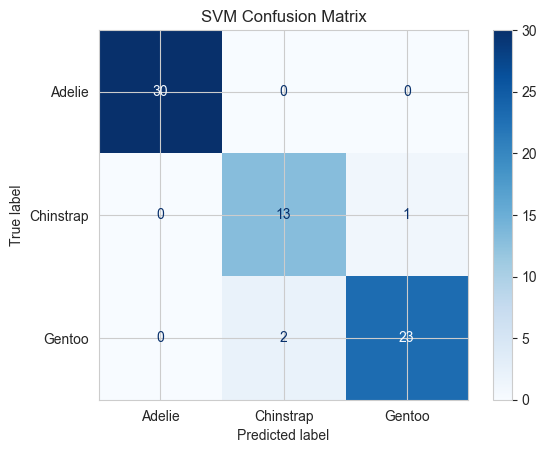


Generating plot with decision boundary...


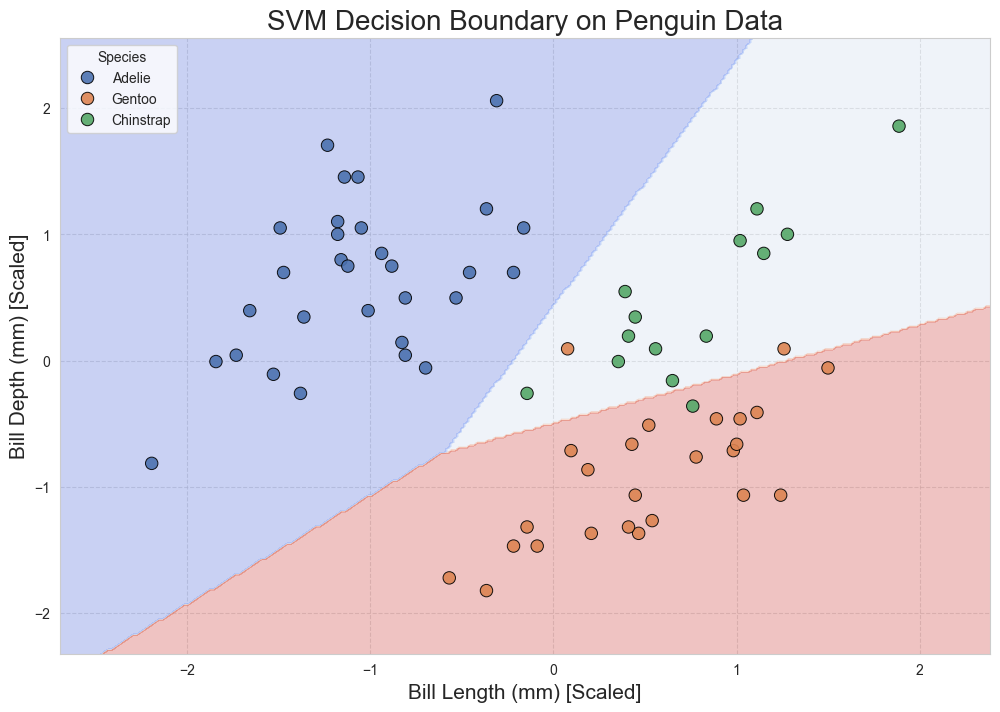

In [10]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Part 1: Load and Initial Data Cleaning ---
# โหลดชุดข้อมูลเพนกวิน
penguins_df = sns.load_dataset("penguins")
print(f"Initial number of rows: {len(penguins_df)}")

# 1.1 เติมค่า null ใน 'sex' ด้วย mode
sex_mode = penguins_df['sex'].mode().iloc[0]
penguins_df['sex'].fillna(sex_mode, inplace=True)

# 1.2 ลบแถวที่มีค่า null ในคอลัมน์สำคัญอื่นๆ
penguins_df.dropna(inplace=True)
penguins_df.reset_index(drop=True, inplace=True)
print(f"Rows after initial cleaning: {len(penguins_df)}")
print("-" * 50)


# --- Part 2: Granular Outlier Detection and IMPUTATION using IQR ---
print("--- Granular Outlier Handling using IQR per Species ---")
penguins_imputed_df = penguins_df.copy() # สร้างสำเนาเพื่อทำการแก้ไข
features_all = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
outlier_indices_to_impute = set()

# Step A: Identify all outliers first
for species in penguins_df['species'].unique():
    species_df = penguins_df[penguins_df['species'] == species]
    for feature in features_all:
        Q1 = species_df[feature].quantile(0.25)
        Q3 = species_df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = species_df[(species_df[feature] < lower_bound) | (species_df[feature] > upper_bound)]
        outlier_indices_to_impute.update(outliers.index)

print(f"Found {len(outlier_indices_to_impute)} outlier entries to impute.")
print("Indices:", sorted(list(outlier_indices_to_impute)))

# Step B: Impute the identified outliers with the species-specific mean
species_means = penguins_df.groupby('species')[features_all].mean()
for idx in outlier_indices_to_impute:
    outlier_species = penguins_imputed_df.loc[idx, 'species']
    imputation_values = species_means.loc[outlier_species]
    # เติมค่าเฉลี่ยลงไปใน DataFrame ที่เราสำเนาไว้
    penguins_imputed_df.loc[idx, features_all] = imputation_values

print(f"\n[SUCCESS] {len(outlier_indices_to_impute)} outlier entries have been imputed.")
print(f"Total rows remains: {len(penguins_imputed_df)}")
print("-" * 50)


# --- Part 3: Model Preparation ---
# 1. เลือก Features ที่ต้องการสำหรับโมเดล (จาก DataFrame ที่ imputed แล้ว)
model_features = ['bill_length_mm', 'bill_depth_mm']
target = 'species'

X = penguins_imputed_df[model_features]
y = penguins_imputed_df[target]

# 2. แบ่งข้อมูลเป็นชุดสำหรับสอน (train) และทดสอบ (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. ปรับสเกลข้อมูล (สำคัญมากสำหรับ SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Part 4: SVM Training and Evaluation ---
# 1. สร้างและสอนโมเดล SVM
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 2. ทำนายผลกับข้อมูลทดสอบ
y_pred = svm_model.predict(X_test_scaled)

# 3. แสดง Classification Report
print("--- SVM Classification Report ---")
report = classification_report(y_test, y_pred)
print(report)

# 4. สร้างและแสดง Confusion Matrix
print("--- Generating Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('SVM Confusion Matrix')
plt.show()


# --- Part 5: Visualization of Decision Boundary ---
print("\nGenerating plot with decision boundary...")

def plot_decision_boundary(X_scaled, y_values, model):
    h = .02
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    species_map = {species: i for i, species in enumerate(model.classes_)}
    Z_numeric = np.array([species_map[label] for label in Z])
    Z_numeric = Z_numeric.reshape(xx.shape)

    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, Z_numeric, cmap=plt.cm.coolwarm, alpha=0.3)

    sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y_values,
                    palette='deep', s=80, edgecolor='k', alpha=0.9)

    plt.title('SVM Decision Boundary on Penguin Data', fontsize=20)
    plt.xlabel('Bill Length (mm) [Scaled]', fontsize=15)
    plt.ylabel('Bill Depth (mm) [Scaled]', fontsize=15)
    plt.legend(title='Species')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_decision_boundary(X_test_scaled, y_test.values, svm_model)



Data has been cleaned and outliers have been imputed.
--------------------------------------------------
Generating PCA plot...


/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64569/3631565704.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguins_df['sex'].fillna(sex_mode, inplace=True)


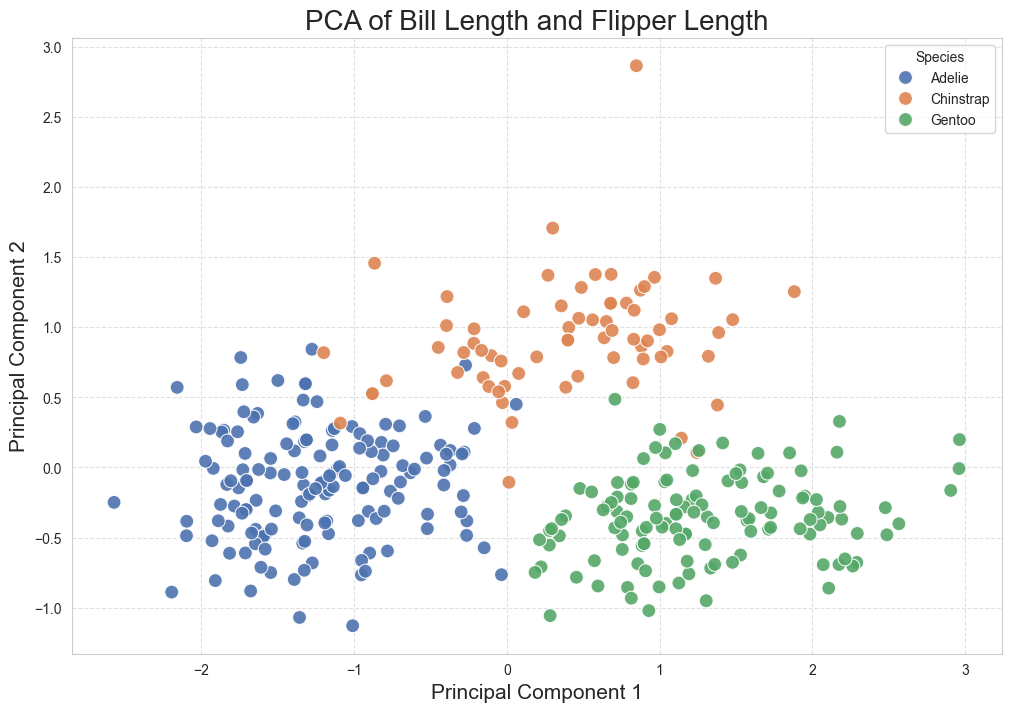

In [11]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Part 1: Load and Prepare Data ---
# ใช้กระบวนการทำความสะอาดข้อมูลที่สมบูรณ์ที่สุดที่เราเคยทำ
penguins_df = sns.load_dataset("penguins")
sex_mode = penguins_df['sex'].mode().iloc[0]
penguins_df['sex'].fillna(sex_mode, inplace=True)
penguins_df.dropna(inplace=True)
penguins_df.reset_index(drop=True, inplace=True)

# จัดการ Outlier ด้วยวิธี IQR Imputation
penguins_imputed_df = penguins_df.copy()
features_all = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
outlier_indices_to_impute = set()
for species in penguins_df['species'].unique():
    species_df = penguins_df[penguins_df['species'] == species]
    for feature in features_all:
        Q1 = species_df[feature].quantile(0.25)
        Q3 = species_df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = species_df[(species_df[feature] < lower_bound) | (species_df[feature] > upper_bound)]
        outlier_indices_to_impute.update(outliers.index)

species_means = penguins_df.groupby('species')[features_all].mean()
for idx in outlier_indices_to_impute:
    outlier_species = penguins_imputed_df.loc[idx, 'species']
    imputation_values = species_means.loc[outlier_species]
    penguins_imputed_df.loc[idx, features_all] = imputation_values

print("Data has been cleaned and outliers have been imputed.")
print("-" * 50)


# --- Part 2: Feature Selection, Scaling, and PCA ---
# เลือก Features ที่คุณต้องการทดลอง
features_for_pca = ['bill_length_mm', 'flipper_length_mm']
X = penguins_imputed_df[features_for_pca]
y = penguins_imputed_df['species']

# ปรับสเกลข้อมูลก่อนทำ PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# สร้างและสอนโมเดล PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# สร้าง DataFrame ใหม่จากผลลัพธ์ของ PCA
pca_df = pd.DataFrame(data=principal_components, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['species'] = y


# --- Part 3: Visualize the PCA Results ---
print("Generating PCA plot...")
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='species',
    data=pca_df,
    palette='deep',
    s=100,
    alpha=0.9
)

plt.title('PCA of Bill Length and Flipper Length', fontsize=20)
plt.xlabel('Principal Component 1', fontsize=15)
plt.ylabel('Principal Component 2', fontsize=15)
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


/tmp/ipython-input-1091571438.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguins_df['sex'].fillna(sex_mode, inplace=True)


--- Granular Outlier Handling: Imputing specific outlier values ---
Calculated Species Means:
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie          38.791391      18.346358         189.953642  3700.662252
Chinstrap       48.833824      18.420588         195.823529  3733.088235
Gentoo          47.504878      14.982114         217.186992  5076.016260
--------------------------------------------------
Found 1 outliers for 'bill_depth_mm' in 'Adelie' species. Imputing with mean...
Found 2 outliers for 'flipper_length_mm' in 'Adelie' species. Imputing with mean...
Found 2 outliers for 'body_mass_g' in 'Chinstrap' species. Imputing with mean...
Found 1 outliers for 'bill_length_mm' in 'Gentoo' species. Imputing with mean...

[SUCCESS] Data has been cleaned and outliers have been imputed.
--------------------------------------------------
Generating PCA plot...


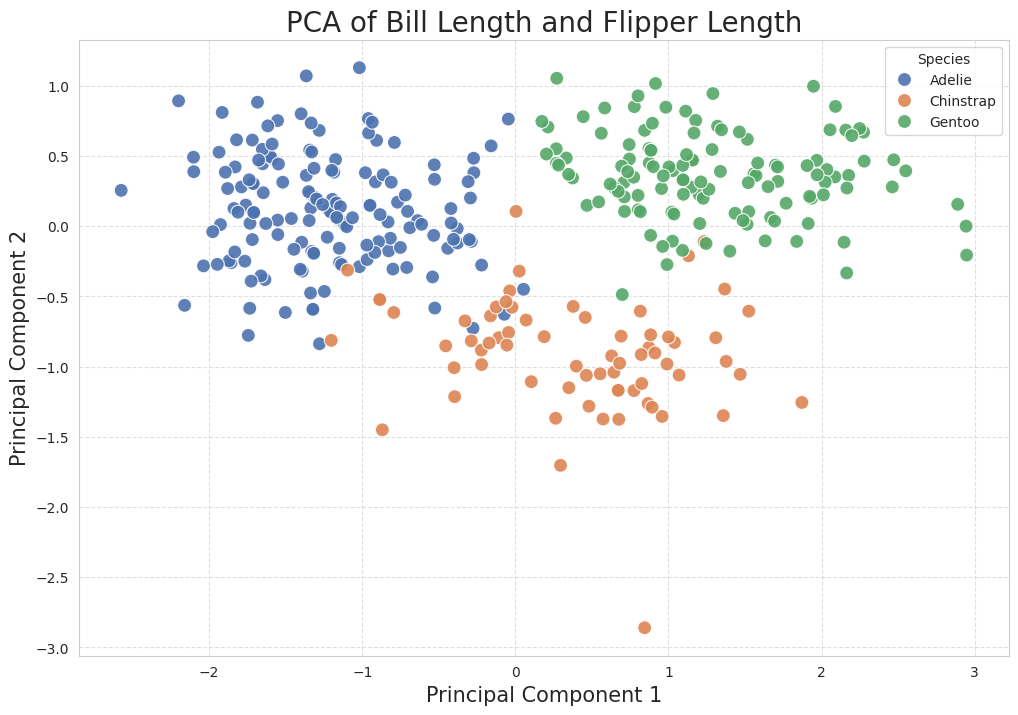

/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64569/3278664705.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguins_df['sex'].fillna(sex_mode, inplace=True)
/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


--- Granular Outlier Handling: Imputing specific outlier values ---
Calculated Species Means:
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie          38.791391      18.346358         189.953642  3700.662252
Chinstrap       48.833824      18.420588         195.823529  3733.088235
Gentoo          47.504878      14.982114         217.186992  5076.016260
--------------------------------------------------
Found 1 outliers for 'bill_depth_mm' in 'Adelie' species. Imputing with mean...
Found 2 outliers for 'flipper_length_mm' in 'Adelie' species. Imputing with mean...
Found 2 outliers for 'body_mass_g' in 'Chinstrap' species. Imputing with mean...
Found 1 outliers for 'bill_length_mm' in 'Gentoo' species. Imputing with mean...

[SUCCESS] Data has been cleaned and outliers have been imputed.
--------------------------------------------------


Generating t-SNE plot...


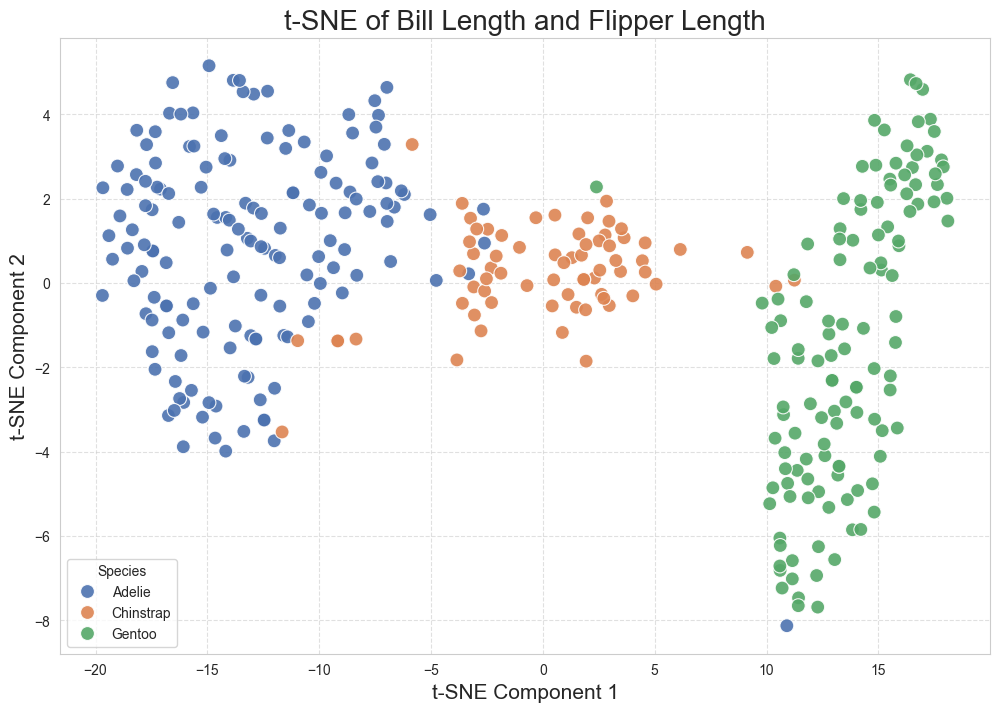

In [12]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# --- Part 1: Load and Prepare Data ---
# ใช้กระบวนการทำความสะอาดข้อมูลที่สมบูรณ์ที่สุดที่เราเคยทำ
penguins_df = sns.load_dataset("penguins")
sex_mode = penguins_df['sex'].mode().iloc[0]
penguins_df['sex'].fillna(sex_mode, inplace=True)
penguins_df.dropna(inplace=True)
penguins_df.reset_index(drop=True, inplace=True)

# --- Part 1.5: Granular Outlier Imputation (Improved Logic) ---
print("--- Granular Outlier Handling: Imputing specific outlier values ---")
penguins_imputed_df = penguins_df.copy()
features_all = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# คำนวณค่าเฉลี่ยของแต่ละ species และ feature เตรียมไว้
species_means = penguins_df.groupby('species')[features_all].mean()
print("Calculated Species Means:")
print(species_means)
print("-" * 50)

# วนลูปในแต่ละสายพันธุ์
for species in penguins_imputed_df['species'].unique():
    # วนลูปในแต่ละ feature
    for feature in features_all:
        # เลือกข้อมูลเฉพาะกลุ่ม (species และ feature)
        subset = penguins_imputed_df[penguins_imputed_df['species'] == species][feature]

        # คำนวณ IQR และขอบเขตสำหรับกลุ่มนี้
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # ค้นหา index ของ outliers ในกลุ่มนี้
        outlier_indices = subset[(subset < lower_bound) | (subset > upper_bound)].index

        if not outlier_indices.empty:
            print(f"Found {len(outlier_indices)} outliers for '{feature}' in '{species}' species. Imputing with mean...")
            # ดึงค่า mean ที่ถูกต้อง (สำหรับ species และ feature นี้)
            imputation_value = species_means.loc[species, feature]
            # เติมค่า mean ลงไปแทนที่ outlier เฉพาะจุดนั้นๆ
            penguins_imputed_df.loc[outlier_indices, feature] = imputation_value

print("\n[SUCCESS] Data has been cleaned and outliers have been imputed.")
print("-" * 50)


# --- Part 2: Feature Selection, Scaling, and t-SNE ---
# เลือก Features ที่คุณต้องการทดลอง
features_for_tsne = ['bill_length_mm', 'flipper_length_mm']
X = penguins_imputed_df[features_for_tsne]
y = penguins_imputed_df['species']

# ปรับสเกลข้อมูลก่อนทำ t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# สร้างและสอนโมเดล t-SNE
# เราใช้ perplexity=50 ที่เคยพบว่าให้ผลดี
tsne = TSNE(n_components=2, perplexity=50, random_state=42, n_iter=1000)
tsne_components = tsne.fit_transform(X_scaled)

# สร้าง DataFrame ใหม่จากผลลัพธ์ของ t-SNE
tsne_df = pd.DataFrame(data=tsne_components, columns=['t-SNE Component 1', 't-SNE Component 2'])
tsne_df['species'] = y


# --- Part 3: Visualize the t-SNE Results ---
print("Generating t-SNE plot...")
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='t-SNE Component 1',
    y='t-SNE Component 2',
    hue='species',
    data=tsne_df,
    palette='deep',
    s=100,
    alpha=0.9
)

plt.title('t-SNE of Bill Length and Flipper Length', fontsize=20)
plt.xlabel('t-SNE Component 1', fontsize=15)
plt.ylabel('t-SNE Component 2', fontsize=15)
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



--- Granular Outlier Handling: Imputing specific outlier values ---

[SUCCESS] Data has been cleaned and outliers have been imputed.
--------------------------------------------------
--- SVM Classification Report ---
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        30
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69

--- Generating Confusion Matrix ---


/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64569/1482365346.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguins_df['sex'].fillna(sex_mode, inplace=True)


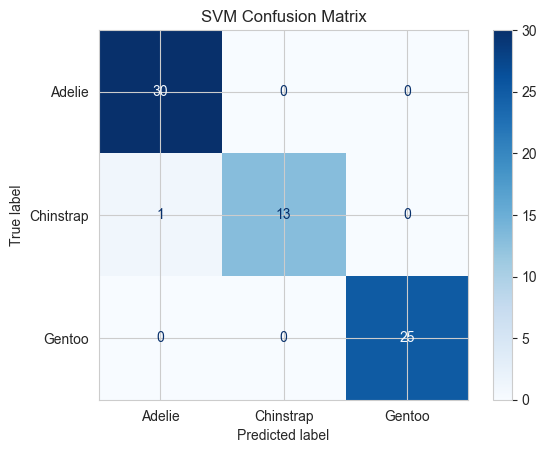


Generating plot with decision boundary...


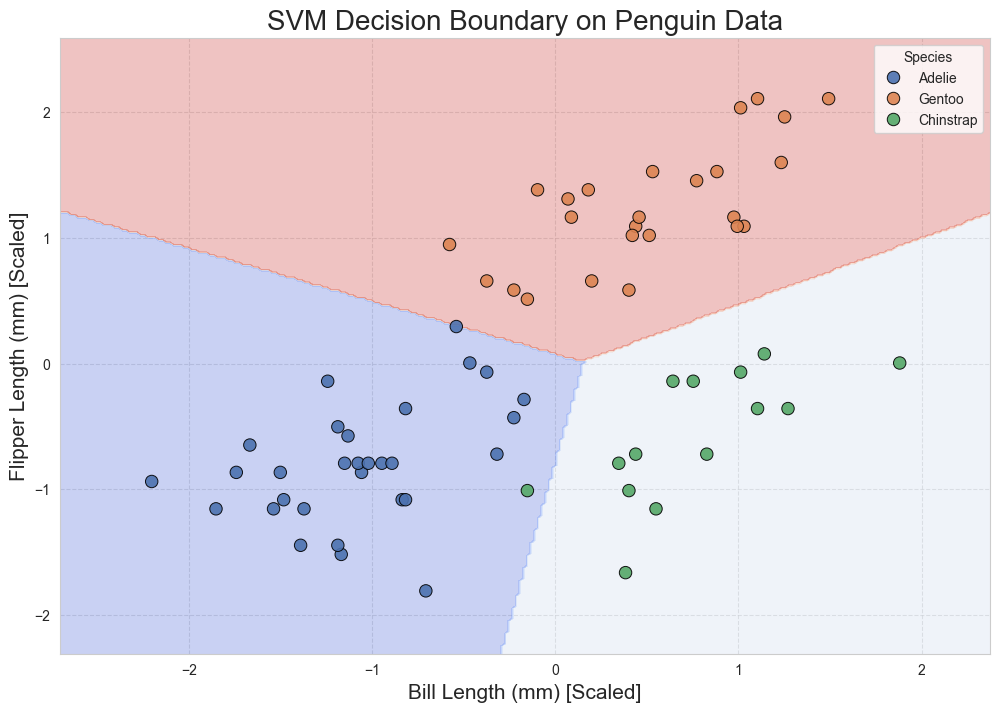

In [13]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Part 1: Load and Prepare Data ---
# ใช้กระบวนการทำความสะอาดข้อมูลที่สมบูรณ์ที่สุดที่เราเคยทำ
penguins_df = sns.load_dataset("penguins")
sex_mode = penguins_df['sex'].mode().iloc[0]
penguins_df['sex'].fillna(sex_mode, inplace=True)
penguins_df.dropna(inplace=True)
penguins_df.reset_index(drop=True, inplace=True)

# --- Part 1.5: Granular Outlier Imputation (Improved Logic) ---
print("--- Granular Outlier Handling: Imputing specific outlier values ---")
penguins_imputed_df = penguins_df.copy()
features_all = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# คำนวณค่าเฉลี่ยของแต่ละ species และ feature เตรียมไว้
species_means = penguins_df.groupby('species')[features_all].mean()

# วนลูปในแต่ละสายพันธุ์และ feature เพื่อหาและเติมค่า outlier
for species in penguins_imputed_df['species'].unique():
    for feature in features_all:
        subset = penguins_imputed_df[penguins_imputed_df['species'] == species][feature]
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_indices = subset[(subset < lower_bound) | (subset > upper_bound)].index

        if not outlier_indices.empty:
            imputation_value = species_means.loc[species, feature]
            penguins_imputed_df.loc[outlier_indices, feature] = imputation_value

print("\n[SUCCESS] Data has been cleaned and outliers have been imputed.")
print("-" * 50)


# --- Part 2: Model Preparation ---
# เลือก Features ที่ต้องการสำหรับโมเดล
model_features = ['bill_length_mm', 'flipper_length_mm']
target = 'species'

X = penguins_imputed_df[model_features]
y = penguins_imputed_df[target]

# แบ่งข้อมูลเป็นชุดสำหรับสอน (train) และทดสอบ (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ปรับสเกลข้อมูล (สำคัญมากสำหรับ SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Part 3: SVM Training and Evaluation ---
# สร้างและสอนโมเดล SVM
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# ทำนายผลกับข้อมูลทดสอบ
y_pred = svm_model.predict(X_test_scaled)

# แสดง Classification Report
print("--- SVM Classification Report ---")
report = classification_report(y_test, y_pred)
print(report)

# สร้างและแสดง Confusion Matrix
print("--- Generating Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('SVM Confusion Matrix')
plt.show()


# --- Part 4: Visualization of Decision Boundary ---
print("\nGenerating plot with decision boundary...")

def plot_decision_boundary(X_scaled, y_values, model):
    h = .02
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    species_map = {species: i for i, species in enumerate(model.classes_)}
    Z_numeric = np.array([species_map[label] for label in Z])
    Z_numeric = Z_numeric.reshape(xx.shape)

    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, Z_numeric, cmap=plt.cm.coolwarm, alpha=0.3)

    sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y_values,
                    palette='deep', s=80, edgecolor='k', alpha=0.9)

    plt.title('SVM Decision Boundary on Penguin Data', fontsize=20)
    plt.xlabel('Bill Length (mm) [Scaled]', fontsize=15)
    plt.ylabel('Flipper Length (mm) [Scaled]', fontsize=15)
    plt.legend(title='Species')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_decision_boundary(X_test_scaled, y_test.values, svm_model)
